# DS12 · Optimization, gradients, and learning rates

<!-- paper-first -->
### Research question

**Reading:** [PP04](../../curriculum/papers/processing.md#pp04). Review the assigned figure or result before starting the lesson.

**Question:** How could an optimizer's behavior change an estimated alignment without changing the scientific target?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Format:** 75–100 minutes of guided work, plus 30–60 minutes in the assigned existing course material. **Prerequisite:** the foundations notebooks; follow this strand in order. The core exercise is synthetic, offline, and independently runnable. It demonstrates mechanics, not a validated participant-data analysis.

## Existing course material

Read [Neuromatch W1D2 Tutorial1: least-squares optimization](https://github.com/NeuromatchAcademy/course-content/blob/44634e960df7a14cd0bf7398187f2d209d26b0e8/tutorials/W1D2_ModelFitting/W1D2_Tutorial1.ipynb). Use the indicated topic, then return here to apply it to a neuroimaging question. Berkeley material is linked in its original form, not adapted or redistributed; its CC BY-NC-ND terms remain upstream. Neuromatch material is CC BY 4.0 with separately licensed software; selected unmodified copies live in `third_party/data_science`. The explanation and dataset below are original.

## Understand the transformation

An optimizer updates parameters to improve a numerical objective. The gradient tells it the local direction of steepest increase, so gradient descent takes a step in the opposite direction. The learning rate controls the step size. A very small step can be slow, while a large step can overshoot or diverge. A decreasing objective verifies progress on that objective, not the validity of the scientific model.

For a one-parameter squared-error model, we can derive the gradient and compare the optimizer with an exact least-squares solution. This is an unusually transparent setting: the objective is convex and has a single optimum when the predictor has nonzero variation. Neural networks generally have a more complicated loss surface, minibatch noise, initialization effects, and regularization choices. Do not generalize the exact convergence guarantee from this toy.

A finite-difference check compares an analytic gradient with a small numerical perturbation of the loss. It can catch a missing factor or sign, but the step size must balance rounding and approximation error. Once an AI produces training code, the learner should demand a loss history, a simple baseline, a gradient check for a small case, and separate validation metrics. Using the test set to choose a learning rate breaks the evaluation boundary.

In this lab a sensible learning rate converges and an oversized rate fails. Preserve the failure: plotting only the successful endpoint hides the mechanism she needs to understand.

## AI-guided prediction

First answer in your own words; then send this to Goose/Ollama or ChatGPT:

> Derive the one-parameter MSE gradient in plain language, check it with finite differences, then compare small and oversized learning rates. Ask me to predict loss curves before running. Distinguish optimizer convergence from generalization.

Use the model as a tutor and snippet writer. Require it to name the axes, units, fitting population, expected output, and one failure check. A code cell that runs is not proof that it answers the scientific question. Keep raw data unchanged and save your actual settings.

## Experiment

Check the gradient at w=.2, run 60 updates, and compare with the closed-form slope. Deliberate error: increase the learning rate to 4 and observe divergence.

Run the following cells in order. Before each, predict what should remain unchanged and what should differ. The assertions test specific mathematical or bookkeeping properties, not clinical validity.

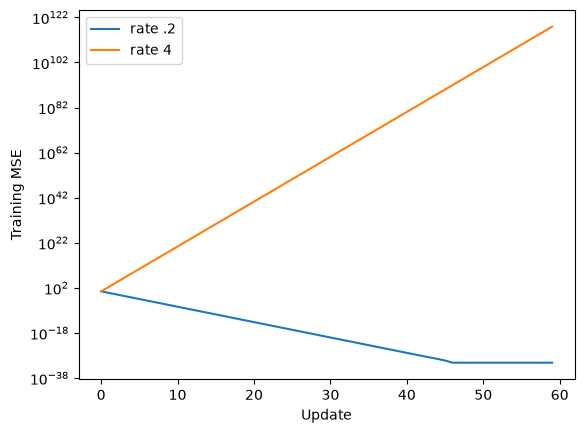

In [1]:
import numpy as np
import matplotlib.pyplot as plt
x=np.linspace(-2,2,100); y=1.5*x
loss=lambda w:np.mean((y-w*x)**2)
grad=lambda w:2*np.mean(x*(w*x-y))
eps=1e-6; fd=(loss(.2+eps)-loss(.2-eps))/(2*eps)
assert np.isclose(fd,grad(.2),rtol=1e-6)
def train(rate):
    w=0.; history=[]
    for _ in range(60):
        history.append(loss(w)); w-=rate*grad(w)
    return w,np.array(history)
w,good=train(.2); _,bad=train(4.)
assert abs(w-1.5)<1e-8 and bad[-1]>bad[0]*100
plt.semilogy(good,label='rate .2'); plt.semilogy(bad,label='rate 4')
plt.xlabel('Update'); plt.ylabel('Training MSE'); plt.legend(); plt.show()

## Explain, break, transfer

1. Save an input → operation → output diagram and state what information was lost.
2. Make the specified wrong choice above. Compare its result with the reference checks; explain why the misleading result is possible.
3. Work through the assigned upstream chapter's example using its own environment or hosted reader. Record one difference between its data and a participant/voxel/time-series dataset.
4. Ask the AI for a short application to a real imaging table, but do not run it until participant identifiers, units, missingness, and any training/test boundary are explicit. Never infer those properties from the column names alone.

**Evidence to submit:** one labeled result, the changed parameter, a failure diagnosis, and a five-sentence interpretation that separates a computational check from the research claim. Explain the result without looking at the model's wording.

<details><summary>Instructor check / answer guide</summary>

The finite difference agrees with the analytic gradient. Learning rate .2 reaches the optimum; rate4 increases the loss sharply for the supplied predictor. Neither outcome validates a biological mechanism.

</details>

**Scope:** This local notebook and its numerical checks are part of the executable core. Completion of the external chapter is a learner assignment; its execution is not implied by the local result. No endorsement by the source authors or USC is implied.

### Return to the research question

Revisit [PP04](../../curriculum/papers/processing.md#pp04) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
